In [7]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import time
import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# from Caching.curve_store import CurveStore
# store = CurveStore()
# df = store.read_raw_day("USD-SOFR-1D-Q12STIRT", datetime.date(2026, 3, 10))
# print(f"{len(df)} snapshots, time range: {df['timestamp_utc'].min()} → {df['timestamp_utc'].max()}")


In [8]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure, IRSwapValue

from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.IRSwaps.BARCHART_STIRF.rl import plot_overnight_forward_curves

from BT.misc import ql_cal_date_range

In [24]:
# curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")

# START = CHI_tz.localize(datetime.datetime(2026, 3, 12, 14, 00))
# END = CHI_tz.localize(datetime.datetime(2026, 3, 12, 15, 0))
# START = NY_tz.localize(datetime.datetime(2026, 3, 5, 10, 00))
# END = NY_tz.localize(datetime.datetime(2026, 3, 3, 11, 00))
# FREQ = "1min" 

# cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
# ts_range = ql_cal_date_range(
#     cal,
#     start=START,
#     end=END,
#     freq=FREQ,
# )
# # curve_mdp.bulk_get_data(request=dict(curve_name="USD-SOFR-1D-Q12STIRT", timestamps=ts_range))
# curve_mdp.bulk_get_data(
#     request={
#         "curve_name": "USD-SOFR-1D-Q12STIRT",
#         "timestamps": ts_range,
#         "show_tqdm": True,
#     }
# )

# Convexity Adjustment Example for Z27 using STIRT curve (built with just futures) and Eris (no jumps) curve

In [110]:
eod = NY_tz.localize(datetime.datetime(2026, 3, 13, 17, 00))

In [111]:
no_cvx_curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")

no_cvx_handle = no_cvx_curve_mdp.get_pricer(
    request=dict(
        curve_name="USD-SOFR-1D-Q12STIRT",
        timestamp=eod,
    )
)
no_cvx_handle

RLIRSwapCurve(_rl_curve_id='USD-SOFR-1D', _rl_curve_handle=<rl.Curve:USD-SOFR-1D at 0x2a580162ea0>, _meta_data={'timestamp': datetime.datetime(2026, 3, 13, 17, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>), 'id': 'BARCHART_STIRF-RL-USD-SOFR-1D-Q12STIRT-2026-03-13 17:00:00-04:00', 'requested_curve_name': 'USD-SOFR-1D-Q12STIRT', 'curve_name': 'USD-SOFR-1D-Q12STIRT'})

In [112]:
with_cvx_curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC-NOJUMPS")

with_cvx_handle = with_cvx_curve_mdp.get_pricer(
    request=dict(
        curve_name="USD-SOFR-1D",
        timestamp=eod,
    )
)
with_cvx_handle

RLIRSwapCurve(_rl_curve_id='USD-SOFR-1D', _rl_curve_handle=<rl.Curve:ERIS_EOD_LIVE-RL_BASIC-NOJUMPS-USD-SOFR-1D-2026-03-13_nojumps-2026-03-13 15:00:00-04:00 at 0x2a5a9bcc940>, _meta_data={'timestamp': datetime.datetime(2026, 3, 13, 15, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>), 'id': 'ERIS_EOD_LIVE-RL_BASIC-NOJUMPS-USD-SOFR-1D-2026-03-13'})

In [118]:
risk = 10_000

query = IRSwapQuery(tenor="IMM_Z27xIMM_H28", structure_kwargs={"bpv": risk})

with_cvx_pkg, with_cvx_rws = query.resolve_package(pricer_or_curve=with_cvx_handle) 
with_cvx_vmap = query.build_value_map(pricer_or_curve=with_cvx_handle, package=with_cvx_pkg, risk_weights=with_cvx_rws)
print("with cvx: ", with_cvx_vmap.apply(value=IRSwapValue.RATE))

no_cvx_pkg, no_cvx_rws = query.resolve_package(pricer_or_curve=no_cvx_handle) 
no_cvx_vmap = query.build_value_map(pricer_or_curve=no_cvx_handle, package=no_cvx_pkg, risk_weights=no_cvx_rws)
print("no cvx: ", no_cvx_vmap.apply(value=IRSwapValue.RATE))

print("cvx adjustment (bp): ", (no_cvx_vmap.apply(value=IRSwapValue.RATE) - with_cvx_vmap.apply(value=IRSwapValue.RATE)) * 100)

with cvx:  3.3228300127897037
no cvx:  3.345523086021858
cvx adjustment (bp):  2.2693073232154415


In [ ]:
IRSwapValue.TRUE_ASW

# Convexity Adjustment Example for Z27 using STIRT curve (built with just futures) and GSQuant Curve

In [83]:
eod = NY_tz.localize(datetime.datetime(2026, 3, 13, 17, 00))

In [84]:
no_cvx_curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")

no_cvx_handle = no_cvx_curve_mdp.get_pricer(
    request=dict(
        curve_name="USD-SOFR-1D-Q12STIRT",
        timestamp=eod,
    )
)
no_cvx_handle

RLIRSwapCurve(_rl_curve_id='USD-SOFR-1D', _rl_curve_handle=<rl.Curve:USD-SOFR-1D at 0x2a580162ea0>, _meta_data={'timestamp': datetime.datetime(2026, 3, 13, 17, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>), 'id': 'BARCHART_STIRF-RL-USD-SOFR-1D-Q12STIRT-2026-03-13 17:00:00-04:00', 'requested_curve_name': 'USD-SOFR-1D-Q12STIRT', 'curve_name': 'USD-SOFR-1D-Q12STIRT'})

In [104]:
with_cvx_curve_mdp = IRSwapsMDP(source="GSQUANT-RL")

with_cvx_handle = with_cvx_curve_mdp.get_pricer(
    request=dict(
        curve_name="USD-SOFR-1D-STIR-CME",
        timestamp=eod.date(),
        force_refresh=True
    )
)
with_cvx_handle

tenor
USD Swap SOFR 1m ATM 0b to 1m CME Cleared      3.686967
USD Swap SOFR 2m ATM 0b to 2m CME Cleared      3.688900
USD Swap SOFR 3m ATM 0b to 3m CME Cleared      3.690301
USD Swap SOFR 6m ATM 0b to 6m CME Cleared      3.677075
USD Swap SOFR 9m ATM 0b to 9m CME Cleared      3.659679
USD Swap SOFR ATM frb1 to frb2 CME Cleared     3.686866
USD Swap SOFR ATM frb2 to frb3 CME Cleared     3.677008
USD Swap SOFR ATM frb3 to frb4 CME Cleared     3.638582
USD Swap SOFR ATM frb4 to frb5 CME Cleared     3.606649
USD Swap SOFR ATM frb5 to frb6 CME Cleared     3.560508
USD Swap SOFR ATM frb6 to frb7 CME Cleared     3.549786
USD Swap SOFR 3m ATM imm1 to 3m CME Cleared    3.690075
USD Swap SOFR 3m ATM imm2 to 3m CME Cleared    3.629631
USD Swap SOFR 3m ATM imm3 to 3m CME Cleared    3.559028
USD Swap SOFR 3m ATM imm4 to 3m CME Cleared    3.497766
USD Swap SOFR 6m ATM imm1 to 6m CME Cleared    3.676781
USD Swap SOFR 6m ATM imm2 to 6m CME Cleared    3.610657
USD Swap SOFR 6m ATM imm3 to 6m CME Cleare

RLIRSwapCurve(_rl_curve_id='USD-SOFR-1D-STIR-CME', _rl_curve_handle=<rl.Curve:2026-03-13-GSQUANT-rl_basic_USD-SOFR-1D-STIR-CME at 0x2a5a9bcdf30>, _meta_data={'timestamp': datetime.date(2026, 3, 13), 'id': '2026-03-13-GSQUANT-rl_basic_USD-SOFR-1D-STIR-CME', 'pricing_location': 'NYC', 'curve_name': 'USD-SOFR-1D-STIR-CME', 'requested_curve_name': 'USD-SOFR-1D-STIR-CME', 'reference_curve_name': 'USD-SOFR-1D'})

(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x2a5b20a8e10>])

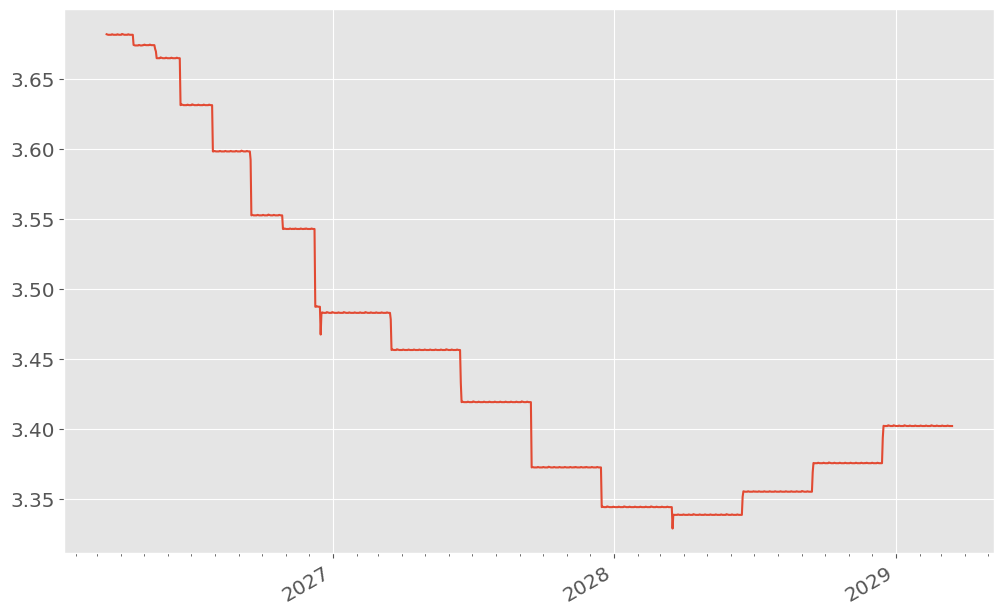

In [105]:
with_cvx_handle.handle().plot("1d")

In [108]:
risk = 10_000

query = IRSwapQuery(tenor="IMM_M26xIMM_U26", structure_kwargs={"bpv": risk})

with_cvx_pkg, with_cvx_rws = query.resolve_package(pricer_or_curve=with_cvx_handle) 
with_cvx_vmap = query.build_value_map(pricer_or_curve=with_cvx_handle, package=with_cvx_pkg, risk_weights=with_cvx_rws)
print("with cvx: ", with_cvx_vmap.apply(value=IRSwapValue.RATE))

no_cvx_pkg, no_cvx_rws = query.resolve_package(pricer_or_curve=no_cvx_handle) 
no_cvx_vmap = query.build_value_map(pricer_or_curve=no_cvx_handle, package=no_cvx_pkg, risk_weights=no_cvx_rws)
print("no cvx: ", no_cvx_vmap.apply(value=IRSwapValue.RATE))

print("cvx adjustment (bp): ", (no_cvx_vmap.apply(value=IRSwapValue.RATE) - with_cvx_vmap.apply(value=IRSwapValue.RATE)) * 100)

with cvx:  3.6296312998216758
no cvx:  3.612689641601459
cvx adjustment (bp):  -1.6941658220216649


# New MDPs

In [11]:
from MDP.IRClearingHouseBasisSwaps.IRClearingHouseBasisSwapsMDP import IRClearingHouseBasisSwapsMDP
from Query.Spreads.SpreadQuery import SpreadQuery, SpreadValue

mdp = IRClearingHouseBasisSwapsMDP()
pricer = mdp.get_pricer({
    "tenor": "10Y",
    "index": "SOFR",
    "start_date": datetime.date(2026, 1, 1),
    "end_date": datetime.date(2026, 2, 20),
})
pricer